# LDA
* Vectorization with BoW
* LDA algorithm
* Evaluation with perplexity and coherence
* Visualization with PCA & UMAP <br>
--> Present topic clusters and top words for optimal k

In [ ]:
import pandas as pd
import numpy as np

from sklearn.feature_extraction.text import CountVectorizer

from sklearn.decomposition import LatentDirichletAllocation
from gensim.models import CoherenceModel
from gensim import corpora
from sklearn.preprocessing import MinMaxScaler

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import textwrap
import seaborn as sns

from sklearn.decomposition import PCA
import umap.umap_ as umap
from sklearn.preprocessing import normalize

import pyLDAvis

In [2]:
df = pd.read_pickle("data/preprocessed_data.pkl")
df

,id,question,link_flair_css_class,link_flair_text,clean_text,tokens
0,421zyl,How is time defined at the big bang?,physics,Physics,time define big bang,"[time, define, big, bang]"
1,4r857d,UFO best scientific explanation. Atmospherical...,geo,Earth Sciences,ufo good scientific explanation atmospherical ...,"[ufo, good, scientific, explanation, atmospher..."
2,4r0zwj,It's a commonly known fact that metals oxidize...,chem,Chemistry,commonly know fact metal oxidize possible dize...,"[commonly, know, fact, metal, oxidize, possibl..."
4,4r191k,Geoscientists: Is there any current research i...,geo,Planetary Sci.,geoscientist current research project shortfal...,"[geoscientist, current, research, project, sho..."
5,4r18ga,"Why are there so many ""accident"" babies yet so...",bio,Biology,accident baby people struggle conceive,"[accident, baby, people, struggle, conceive]"
...,...,...,...,...,...,...
612662,ry6rh0,2 doses of vaccines protect against severe ill...,med,COVID-19,dos vaccine protect severe illness infection m...,"[dos, vaccine, protect, severe, illness, infec..."
612663,ry6of6,Dentists! I've got a question for you: why do ...,med,Medicine,dentist get question dentist labeling advise c...,"[dentist, get, question, dentist, labeling, ad..."
612665,ry6nle,Why don't the oceans get saltier over time? Or...,geo,Earth Sciences,don ocean salty time,"[don, ocean, salty, time]"
612666,rwkxsm,Would tracing paper be classed as translucent ...,physics,Physics,trace paper class translucent transparent like...,"[trace, paper, class, translucent, transparent..."


## BoW

In [3]:
# Create vectorizer
vectorizer = CountVectorizer(max_features=10000, min_df=3, max_df=0.9, stop_words='english')  # remove very rare or overly common words, limit features and specify stopwords

# Fit and transform 'clean text'
X = vectorizer.fit_transform(df["clean_text"])

# Vocabulary size
print(len(vectorizer.vocabulary_))
# Feature names
print(vectorizer.get_feature_names_out())
# Sparse feature matrix
print(X)

10000
['abandon' 'abdomen' 'abdominal' ... 'zoom' 'zoonotic' 'zygote']
<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 3484684 stored elements and shape (506202, 10000)>
  Coords	Values
  (0, 9062)	1
  (0, 2298)	1
  (0, 859)	1
  (0, 747)	1
  (1, 9332)	1
  (1, 3892)	1
  (1, 7817)	1
  (1, 3266)	1
  (1, 3165)	1
  (1, 5580)	1
  (2, 1713)	1
  (2, 4994)	1
  (2, 3329)	1
  (2, 5575)	1
  (2, 6327)	1
  (2, 6802)	1
  (2, 3743)	1
  (3, 2157)	1
  (3, 7496)	1
  (3, 6984)	1
  (3, 4961)	1
  (3, 5666)	1
  (3, 2928)	1
  (3, 2252)	1
  (4, 51)	1
  :	:
  (506198, 407)	1
  (506198, 7675)	1
  (506198, 6907)	1
  (506198, 204)	1
  (506198, 2361)	2
  (506198, 5806)	1
  (506198, 168)	1
  (506199, 9062)	1
  (506199, 2693)	1
  (506199, 6141)	1
  (506199, 7742)	1
  (506200, 4223)	1
  (506200, 3312)	1
  (506200, 5188)	1
  (506200, 6)	1
  (506200, 6376)	1
  (506200, 1539)	1
  (506200, 9209)	1
  (506200, 9202)	1
  (506200, 9159)	1
  (506201, 2829)	1
  (506201, 6610)	1
  (506201, 7900)	1
  (506201, 449)	1
 

## LDA

### Prototype with *k = 10*

In [4]:
n_topics = 10

lda = LatentDirichletAllocation(
    n_components=n_topics,
    learning_method="online",
    batch_size=8192,
    random_state=42,
    max_iter=10,
    n_jobs=-1
)

lda.fit(X)

,"n_components n_components: int, default=10Number of topics... versionchanged:: 0.19 ``n_topics`` was renamed to ``n_components``",10
,"doc_topic_prior doc_topic_prior: float, default=NonePrior of document topic distribution `theta`. If the value is None,defaults to `1 / n_components`.In [1]_, this is called `alpha`.",None
,"topic_word_prior topic_word_prior: float, default=NonePrior of topic word distribution `beta`. If the value is None, defaultsto `1 / n_components`.In [1]_, this is called `eta`.",None
,"learning_method learning_method: {'batch', 'online'}, default='batch'Method used to update `_component`. Only used in :meth:`fit` method.In general, if the data size is large, the online update will be muchfaster than the batch update.Valid options:- 'batch': Batch variational Bayes method. Use all training data in each EM update. Old `components_` will be overwritten in each iteration.- 'online': Online variational Bayes method. In each EM update, use mini-batch of training data to update the ``components_`` variable incrementally. The learning rate is controlled by the ``learning_decay`` and the ``learning_offset`` parameters... versionchanged:: 0.20 The default learning method is now ``""batch""``.",'online'
,"learning_decay learning_decay: float, default=0.7It is a parameter that control learning rate in the online learningmethod. The value should be set between (0.5, 1.0] to guaranteeasymptotic convergence. When the value is 0.0 and batch_size is``n_samples``, the update method is same as batch learning. In theliterature, this is called kappa.",0.7
,"learning_offset learning_offset: float, default=10.0A (positive) parameter that downweights early iterations in onlinelearning. It should be greater than 1.0. In the literature, this iscalled tau_0.",10.0
,"max_iter max_iter: int, default=10The maximum number of passes over the training data (aka epochs).It only impacts the behavior in the :meth:`fit` method, and not the:meth:`partial_fit` method.",10
,"batch_size batch_size: int, default=128Number of documents to use in each EM iteration. Only used in onlinelearning.",8192
,"evaluate_every evaluate_every: int, default=-1How often to evaluate perplexity. Only used in `fit` method.set it to 0 or negative number to not evaluate perplexity intraining at all. Evaluating perplexity can help you check convergencein training process, but it will also increase total training time.Evaluating perplexity in every iteration might increase training timeup to two-fold.",-1
,"total_samples total_samples: int, default=1e6Total number of documents. Only used in the :meth:`partial_fit` method.",1000000.0
,"perp_tol perp_tol: float, default=1e-1Perplexity tolerance. Only used when ``evaluate_every`` is greater than 0.",0.1


In [5]:
def print_topics(model, vectorizer, n_top_words=10):
    words = vectorizer.get_feature_names_out()

    for topic_idx, topic in enumerate(model.components_):
        top_words = [words[i] for i in topic.argsort()[-n_top_words:]]
        print(f"Topic {topic_idx}: {top_words}")

print_topics(lda, vectorizer)

Topic 0: ['level', 'high', 'pressure', 'hot', 'drink', 'food', 'cold', 'temperature', 'air', 'water']
Topic 1: ['different', 'animal', 'specie', 'sound', 'big', 'look', 'year', 'human', 'like', 'universe']
Topic 2: ['plant', 'hair', 'blood', 'hand', 'like', 'eat', 'grow', 'animal', 'body', 'human']
Topic 3: ['long', 'body', 'person', 'effect', 'sleep', 'cause', 'covid', 'virus', 'brain', 'people']
Topic 4: ['gravity', 'happen', 'travel', 'space', 'fast', 'object', 'speed', 'time', 'earth', 'light']
Topic 5: ['electron', 'reaction', 'chemical', 'weight', 'field', 'mass', 'atom', 'particle', 'matter', 'energy']
Topic 6: ['theory', 'explain', 'work', 'good', 'climate', 'scientific', 'question', 'help', 'science', 'change']
Topic 7: ['degree', 'create', 'use', 'oxygen', 'possible', 'build', 'carbon', 'fall', 'heat', 'space']
Topic 8: ['technology', 'use', 'dna', 'number', 'nuclear', 'power', 'possible', 'cell', 'covid', 'vaccine']
Topic 9: ['color', 'moon', 'light', 'like', 'star', 'life',

The prototype seems to work quite well already although *k* needs to be improved. The top words already reveal promising topics, but some topics sound relatively similar to each other and some topics are still a bit vague judging from the top then words. Thus, the best value(s) for *k* need to be identified to improve topic distinctness and sharpness. Evaluation is carried out using the metrics perplexity, coherence and topic diversity.

### Finding the Best Value for *k*

In [6]:
texts = df["tokens"].tolist()
dictionary = corpora.Dictionary(texts)

def train_lda(k, X):
    lda = LatentDirichletAllocation(
        n_components=k,
        learning_method="online",
        max_iter=10,
        random_state=42,
        n_jobs=-1,
        batch_size=8192,
        evaluate_every=-1
    )
    lda.fit(X)
    return lda

In [17]:
def evaluate_model(lda, X, vectorizer, texts, dictionary, top_n=10):

    # Perplexity
    perplexity = lda.perplexity(X)

    # Extract topics
    feature_names = np.array(vectorizer.get_feature_names_out())

    topics = []

    for topic in lda.components_:
        top_words = feature_names[topic.argsort()[-top_n:]]
        topics.append(list(top_words))

    # Coherence
    cm = CoherenceModel(
        topics=topics,
        texts=texts,
        dictionary=dictionary,
        coherence="c_v"
    )

    coherence = cm.get_coherence()

    # Topic diversity
    all_topic_words = []

    for topic in topics:
        all_topic_words.extend(topic)

    diversity = len(set(all_topic_words)) / len(all_topic_words)

    return coherence, perplexity, diversity

In [45]:
# Broad range for k to find sensible range
k_values = range(5, 101, 5)

results = []

for k in k_values:
    print(f"Training LDA with k={k}")

    lda = train_lda(k, X)

    coherence, perplexity, diversity = evaluate_model(
    lda, X, vectorizer, texts, dictionary
    )

    results.append((k, coherence, perplexity, diversity))

Training LDA with k=5
Training LDA with k=10
Training LDA with k=15
Training LDA with k=20
Training LDA with k=25
Training LDA with k=30
Training LDA with k=35
Training LDA with k=40
Training LDA with k=45
Training LDA with k=50
Training LDA with k=55
Training LDA with k=60
Training LDA with k=65
Training LDA with k=70
Training LDA with k=75
Training LDA with k=80
Training LDA with k=85
Training LDA with k=90
Training LDA with k=95
Training LDA with k=100


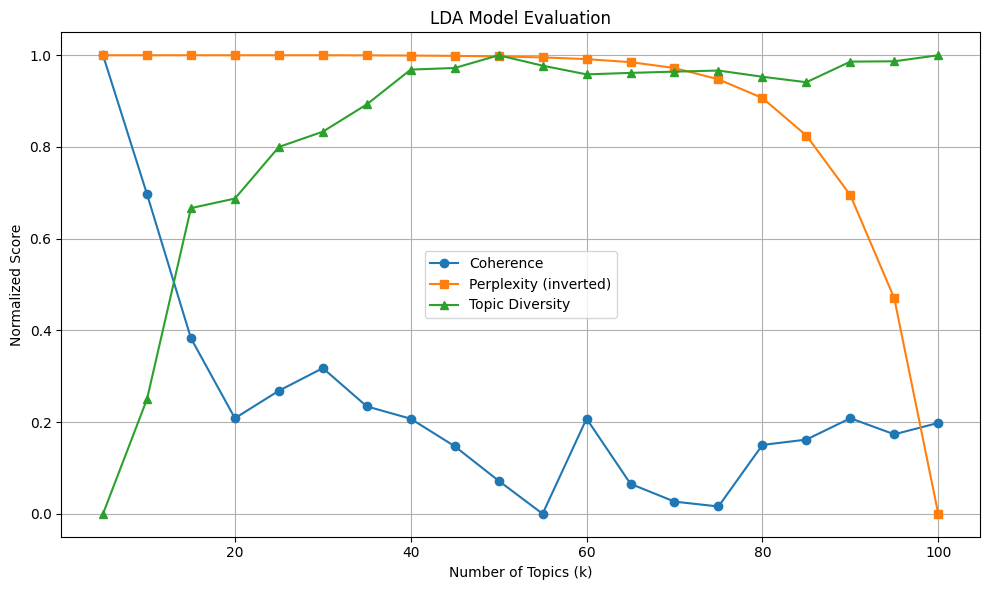

In [46]:
k_vals = [r[0] for r in results]

coherence = np.array([r[1] for r in results]).reshape(-1, 1)
perplexity = np.array([r[2] for r in results]).reshape(-1, 1)
diversity = np.array([r[3] for r in results]).reshape(-1, 1)

scaler = MinMaxScaler()

coherence_norm = scaler.fit_transform(coherence).flatten()

# Invert perplexity (lower score is better)
perplexity_norm = 1 - scaler.fit_transform(perplexity).flatten()

diversity_norm = scaler.fit_transform(diversity).flatten()

plt.figure(figsize=(10,6))

plt.plot(
    k_vals,
    coherence_norm,
    marker='o',
    label='Coherence'
)

plt.plot(
    k_vals,
    perplexity_norm,
    marker='s',
    label='Perplexity (inverted)'
)

plt.plot(
    k_vals,
    diversity_norm,
    marker='^',
    label='Topic Diversity'
)

plt.xlabel("Number of Topics (k)")
plt.ylabel("Normalized Score")
plt.title("LDA Model Evaluation")

plt.legend()
plt.grid()

plt.tight_layout()

plt.savefig('viz/LDA_evaluation_metrics.png', dpi=300)

plt.show()

From the broad overview two relevant areas can be identified. The inverted perplexity score stays relatively constant until k=55 and drops afterwards indicating that *k* should be *< 55*. The coherence score drops sharply right in the beginning and shows two smaller spikes at *k = 30* and *k = 60*. A higher coherence score is desirable for sematically meaniful topics which seems to be quite difficult here. As an additional metric topic diversity was plotted to measure the disctincness of topics. Unlike the coeherence score it rises rapidly with increasing *k* until its peak at *k = 50*. A good tradeoff between coherence and diversity seems to be in the range *k = 5* to *k = 35* which will be investigated with smaller steps in the following.

Training LDA with k=5
Training LDA with k=6
Training LDA with k=7
Training LDA with k=8
Training LDA with k=9
Training LDA with k=10
Training LDA with k=11
Training LDA with k=12
Training LDA with k=13
Training LDA with k=14
Training LDA with k=15
Training LDA with k=16
Training LDA with k=17
Training LDA with k=18
Training LDA with k=19
Training LDA with k=20
Training LDA with k=21
Training LDA with k=22
Training LDA with k=23
Training LDA with k=24
Training LDA with k=25
Training LDA with k=26
Training LDA with k=27
Training LDA with k=28
Training LDA with k=29
Training LDA with k=30
Training LDA with k=31
Training LDA with k=32
Training LDA with k=33
Training LDA with k=34
Training LDA with k=35
Training LDA with k=36
Training LDA with k=37
Training LDA with k=38
Training LDA with k=39
Training LDA with k=40


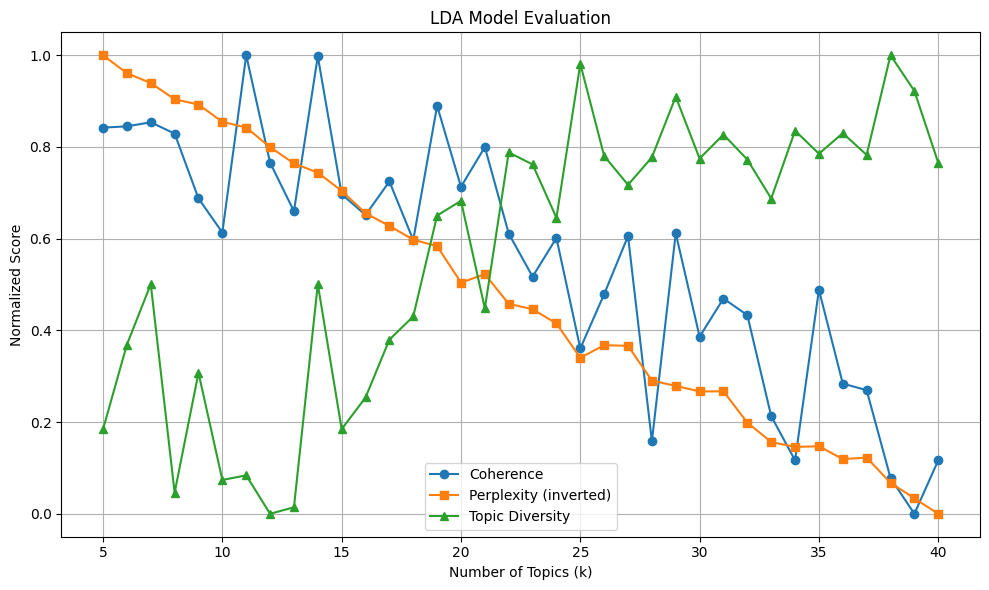

In [ ]:
# Narrow range for k to find the best k
k_values = range(5, 36, 1)

results = []

for k in k_values:
    print(f"Training LDA with k={k}")

    lda = train_lda(k, X)

    coherence, perplexity, diversity = evaluate_model(
    lda, X, vectorizer, texts, dictionary
    )

    results.append((k, coherence, perplexity, diversity))

k_vals = [r[0] for r in results]

coherence = np.array([r[1] for r in results]).reshape(-1, 1)
perplexity = np.array([r[2] for r in results]).reshape(-1, 1)
diversity = np.array([r[3] for r in results]).reshape(-1, 1)

scaler = MinMaxScaler()

coherence_norm = scaler.fit_transform(coherence).flatten()

# Invert perplexity (lower score is better)
perplexity_norm = 1 - scaler.fit_transform(perplexity).flatten()

diversity_norm = scaler.fit_transform(diversity).flatten()

plt.figure(figsize=(10,6))

plt.plot(
    k_vals,
    coherence_norm,
    marker='o',
    label='Coherence'
)

plt.plot(
    k_vals,
    perplexity_norm,
    marker='s',
    label='Perplexity (inverted)'
)

plt.plot(
    k_vals,
    diversity_norm,
    marker='^',
    label='Topic Diversity'
)

plt.xlabel("Number of Topics (k)")
plt.ylabel("Normalized Score")
plt.title("LDA Model Evaluation")

plt.legend()
plt.grid()

plt.tight_layout()

plt.savefig('viz/LDA_evaluation_metrics.png', dpi=300)

plt.show()

### Final Run with Best Values for *k*

In [7]:
def show_topics(model, vectorizer, n_words=10):
    words = vectorizer.get_feature_names_out()

    for i, topic in enumerate(model.components_):
        top_words = [words[j] for j in topic.argsort()[-n_words:]]
        print(f"Topic {i}: {top_words}")

In [ ]:
def plot_2D_projection(lda, X, k):

    # Document-topic matrix
    doc_topics = lda.transform(X).astype("float32")

    # Remove weak memberships
    doc_topics[doc_topics < 0.05] = 0

    # Renormalize
    doc_topics = normalize(doc_topics, norm='l1')

    # Dominant topic
    dominant_topic = doc_topics.argmax(axis=1)
    num_topics = doc_topics.shape[1]

    # Colors based on dominant topic
    cmap = plt.colormaps.get_cmap('tab20')
    topic_colors = [cmap(t % 20) for t in dominant_topic]

    sns.set_theme(style='whitegrid', context='paper')
    spine_color = '#cccccc'

    # PCA
    pca = PCA(n_components=2, svd_solver='randomized', random_state=42)
    W_pca = pca.fit_transform(doc_topics)

    # Denoise with PCA
    doc_topics = PCA(n_components=10).fit_transform(doc_topics)

    reducer = umap.UMAP(
        n_components=2,
        n_neighbors=15,
        min_dist=0.5,
        metric='euclidean',
        n_jobs=-1
    )

    W_umap = reducer.fit_transform(doc_topics)

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    titles = ["PCA Projection", "UMAP Projection"]

    for ax, emb, title in zip(axes, [W_pca, W_umap], titles):
        ax.scatter(
            emb[:, 0], emb[:, 1],
            c=topic_colors,
            s=6,
            alpha=0.6
        )

        ax.set_title(f"{title} of LDA Topic Space (k={k})", fontsize=15)
        ax.set_xlabel("Component 1")
        ax.set_ylabel("Component 2")
        ax.grid(alpha=0.3)

        for spine in ax.spines.values():
            spine.set_color(spine_color)

    # Legend
    legend_elements = [
        Line2D(
            [0], [0],
            marker='o', color='w',
            markerfacecolor=cmap(t % 20),
            markersize=8,
            label=f"Topic {t}"
        )
        for t in range(num_topics)
    ]

    axes[1].legend(
        handles=legend_elements,
        title="Topics",
        bbox_to_anchor=(1.05, 1),
        loc='upper left',
        frameon=False
    )

    plt.tight_layout()
    plt.show()

In [47]:
best_k = [11, 14, 19]

for k in best_k:

    print(f"Training LDA with k={k}")

    lda = train_lda(k, X)

    show_topics(lda, vectorizer)

    # PCA
    plot_2D_projection(lda, X, k)

Training LDA with k=11
Topic 0: ['oxygen', 'hot', 'smell', 'body', 'blood', 'cold', 'eat', 'temperature', 'air', 'food']
Topic 1: ['people', 'thing', 'feel', 'hear', 'look', 'big', 'sleep', 'brain', 'sound', 'like']
Topic 2: ['turn', 'ocean', 'drink', 'liquid', 'happen', 'ice', 'skin', 'hand', 'eye', 'water']
Topic 3: ['long', 'test', 'disease', 'person', 'cause', 'effect', 'virus', 'people', 'vaccine', 'covid']
Topic 4: ['period', 'earth', 'hit', 'fall', 'long', 'day', 'stop', 'car', 'time', 'happen']
Topic 5: ['physical', 'evolutionary', 'dog', 'people', 'evolve', 'like', 'specie', 'different', 'animal', 'human']
Topic 6: ['learn', 'scientist', 'good', 'climate', 'scientific', 'work', 'question', 'help', 'change', 'science']
Topic 7: ['quantum', 'atom', 'theory', 'field', 'possible', 'particle', 'create', 'wave', 'matter', 'energy']
Topic 8: ['nuclear', 'evolution', 'radiation', 'possible', 'long', 'grow', 'body', 'live', 'cell', 'human']
Topic 9: ['orbit', 'like', 'star', 'moon', 'l

KeyboardInterrupt: 

In [8]:
k = 11

print(f"Training LDA with k={k}")

lda = train_lda(k, X)

show_topics(lda, vectorizer)

# Viz
viz = pyLDAvis.lda_model.prepare(
lda,
X,
vectorizer
)

pyLDAvis.display(viz)

Training LDA with k=11
Topic 0: ['oxygen', 'hot', 'smell', 'body', 'blood', 'cold', 'eat', 'temperature', 'air', 'food']
Topic 1: ['people', 'thing', 'feel', 'hear', 'look', 'big', 'sleep', 'brain', 'sound', 'like']
Topic 2: ['turn', 'ocean', 'drink', 'liquid', 'happen', 'ice', 'skin', 'hand', 'eye', 'water']
Topic 3: ['long', 'test', 'disease', 'person', 'cause', 'effect', 'virus', 'people', 'vaccine', 'covid']
Topic 4: ['period', 'earth', 'hit', 'fall', 'long', 'day', 'stop', 'car', 'time', 'happen']
Topic 5: ['physical', 'evolutionary', 'dog', 'people', 'evolve', 'like', 'specie', 'different', 'animal', 'human']
Topic 6: ['learn', 'scientist', 'good', 'climate', 'scientific', 'work', 'question', 'help', 'change', 'science']
Topic 7: ['quantum', 'atom', 'theory', 'field', 'possible', 'particle', 'create', 'wave', 'matter', 'energy']
Topic 8: ['nuclear', 'evolution', 'radiation', 'possible', 'long', 'grow', 'body', 'live', 'cell', 'human']
Topic 9: ['orbit', 'like', 'star', 'moon', 'l

In [11]:
k = 14

print(f"Training LDA with k={k}")

lda = train_lda(k, X)

show_topics(lda, vectorizer)

# Viz
viz = pyLDAvis.lda_model.prepare(
lda,
X,
vectorizer
)

pyLDAvis.display(viz)

Training LDA with k=14
Topic 0: ['metal', 'element', 'material', 'pressure', 'gas', 'low', 'high', 'heat', 'temperature', 'air']
Topic 1: ['atom', 'energy', 'force', 'particle', 'matter', 'mass', 'big', 'hole', 'black', 'universe']
Topic 2: ['glass', 'ice', 'happen', 'hot', 'ocean', 'skin', 'drink', 'hand', 'cold', 'water']
Topic 3: ['happen', 'old', 'person', 'age', 'body', 'cause', 'sleep', 'feel', 'people', 'brain']
Topic 4: ['stop', 'hit', 'fall', 'solar', 'orbit', 'moon', 'sun', 'planet', 'happen', 'earth']
Topic 5: ['female', 'physical', 'male', 'acid', 'cat', 'dog', 'like', 'different', 'human', 'animal']
Topic 6: ['warming', 'evidence', 'technology', 'language', 'global', 'car', 'current', 'climate', 'cell', 'change']
Topic 7: ['day', 'taste', 'weight', 'people', 'bad', 'smell', 'eat', 'food', 'covid', 'vaccine']
Topic 8: ['evolution', 'term', 'body', 'time', 'specie', 'evolve', 'year', 'live', 'long', 'human']
Topic 9: ['red', 'form', 'possible', 'exist', 'number', 'color', 'e

In [12]:
k = 19

print(f"Training LDA with k={k}")

lda = train_lda(k, X)

show_topics(lda, vectorizer)

# Viz
viz = pyLDAvis.lda_model.prepare(
lda,
X,
vectorizer
)

pyLDAvis.display(viz)

Training LDA with k=19
Topic 0: ['temperature', 'taste', 'level', 'ocean', 'pressure', 'smell', 'hot', 'cold', 'air', 'water']
Topic 1: ['cat', 'expand', 'time', 'dog', 'exist', 'size', 'small', 'sound', 'big', 'universe']
Topic 2: ['melt', 'heat', 'leave', 'solid', 'cool', 'liquid', 'element', 'skin', 'water', 'ice']
Topic 3: ['cell', 'develop', 'benefit', 'genetic', 'immune', 'disease', 'natural', 'health', 'cancer', 'bacteria']
Topic 4: ['zero', 'start', 'line', 'degree', 'happen', 'earth', 'second', 'stop', 'sun', 'temperature']
Topic 5: ['structure', 'female', 'sex', 'plastic', 'male', 'woman', 'hand', 'man', 'like', 'look']
Topic 6: ['think', 'learn', 'impact', 'scientist', 'explain', 'climate', 'question', 'science', 'help', 'change']
Topic 7: ['prove', 'law', 'experiment', 'physics', 'state', 'electron', 'quantum', 'number', 'theory', 'particle']
Topic 8: ['half', 'radiation', 'time', 'period', 'modern', 'occur', 'scientific', 'mar', 'nuclear', 'life']
Topic 9: ['happen', 'grav

## Plot Results

In [ ]:
# Add topic to df
doc_topic = lda.transform(X)
df["dominant_topic"] = np.argmax(doc_topic, axis=1)

In [ ]:
for topic in range(n_topics):
    print(f"\nTopic {topic}")
    print(df[df["dominant_topic"] == topic]["clean_text"].head(3))

In [ ]:
# table of top words

In [ ]:
# bar chart of posts per topic